In [116]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv
/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv


In [117]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/gokulrajkmv/unemployment-in-india


In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [119]:
df = pd.read_csv('/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv')

df.head(20)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,31-10-2019,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,30-11-2019,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,31-12-2019,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,31-01-2020,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,29-02-2020,Monthly,5.91,11723617.0,42.83,Rural


In [120]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(768, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 E

In [121]:
df.columns = df.columns.str.strip()

df.rename(columns={
    'Region':'State',
    'Estimated Unemployment Rate (%)':'Unemployment_Rate',
    'Estimated Employed':'Employed',
    'Estimated Labour Participation Rate (%)':'Labour_Participation_Rate'
}, inplace=True)

df.head()

,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [122]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [123]:
print(df[['Date', 'Month', 'Year']].head())

        Date  Month    Year
0 2019-05-31    5.0  2019.0
1 2019-06-30    6.0  2019.0
2 2019-07-31    7.0  2019.0
3 2019-08-31    8.0  2019.0
4 2019-09-30    9.0  2019.0


In [124]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Month,Year
count,740,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122,6.390541,2019.418919
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,1.000000,2019.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,4.000000,2019.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,6.000000,2019.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,9.000000,2020.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,12.000000,2020.000000
std,NaN,10.721298,8.087988e+06,8.111094,3.235070,0.493716


In [125]:
state_unemployment = df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False)

print(state_unemployment.head(10))

State
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment_Rate, dtype: float64


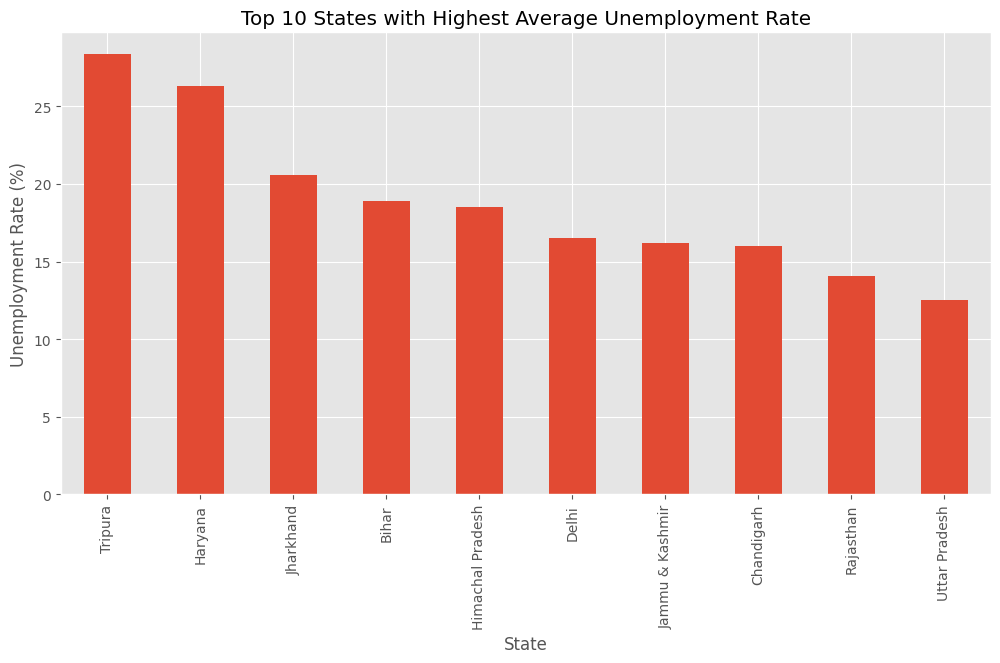

In [126]:
plt.figure(figsize=(12,6))

state_unemployment.head(10).plot(kind='bar')

plt.title('Top 10 States with Highest Average Unemployment Rate')
plt.ylabel('Unemployment Rate (%)')
plt.show()

In [127]:
state_avg = df.groupby('State')['Unemployment_Rate'].mean()

print("Top 10 Highest")
print(state_avg.sort_values(ascending=False).head(10))

print("\nTop 10 Lowest")
print(state_avg.sort_values().head(10))

Top 10 Highest
State
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment_Rate, dtype: float64

Top 10 Lowest
State
Meghalaya         4.798889
Odisha            5.657857
Assam             6.428077
Uttarakhand       6.582963
Gujarat           6.663929
Karnataka         6.676071
Sikkim            7.249412
Madhya Pradesh    7.406429
Andhra Pradesh    7.477143
Maharashtra       7.557500
Name: Unemployment_Rate, dtype: float64


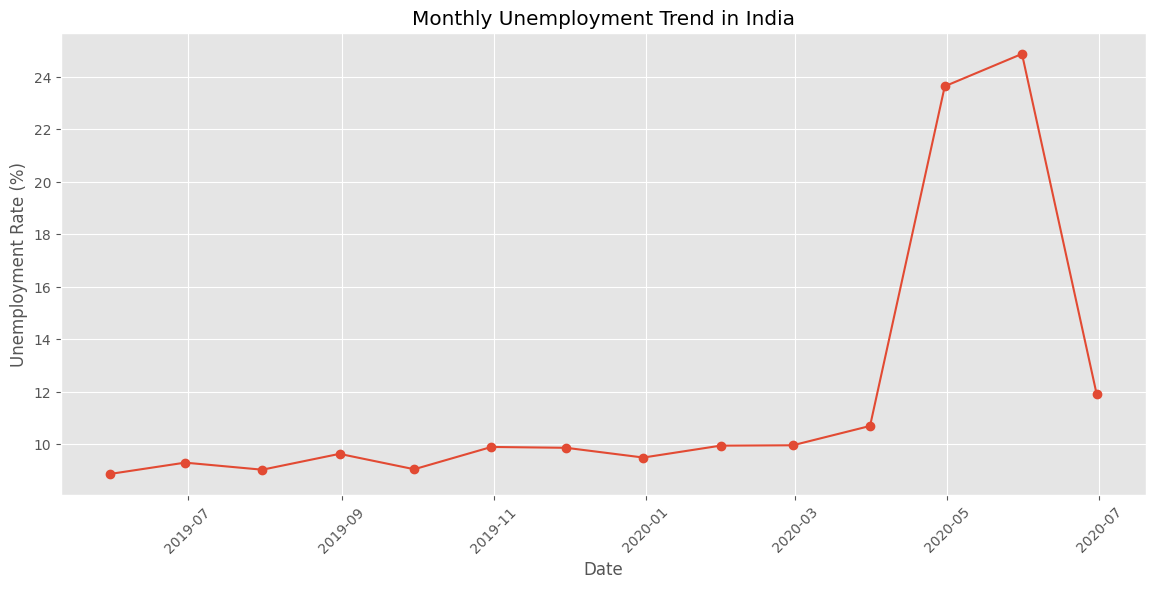

In [128]:
monthly = df.groupby('Date')['Unemployment_Rate'].mean()

plt.figure(figsize=(14,6))
plt.plot(monthly.index, monthly.values, marker='o')

plt.title('Monthly Unemployment Trend in India')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.show()

In [129]:
before_covid = df[df['Date'] < '2020-04-01']
during_covid = df[df['Date'] >= '2020-04-01']

print("Before Covid Mean Unemployment:",
      before_covid['Unemployment_Rate'].mean())

print("During Covid Mean Unemployment:",
      during_covid['Unemployment_Rate'].mean())

Before Covid Mean Unemployment: 9.61486394557823
During Covid Mean Unemployment: 20.194342105263157


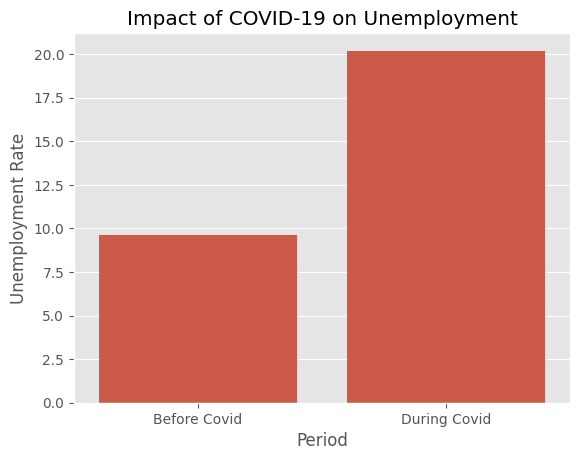

In [130]:
covid_compare = pd.DataFrame({
    'Period':['Before Covid','During Covid'],
    'Unemployment Rate':[
        before_covid['Unemployment_Rate'].mean(),
        during_covid['Unemployment_Rate'].mean()
    ]
})

sns.barplot(data=covid_compare,
            x='Period',
            y='Unemployment Rate')

plt.title('Impact of COVID-19 on Unemployment')
plt.show()

In [131]:
before = df[df['Date'] < '2020-04-01']
during = df[df['Date'] >= '2020-04-01']

before_mean = before['Unemployment_Rate'].mean()
during_mean = during['Unemployment_Rate'].mean()

increase = ((during_mean-before_mean)/before_mean)*100

print(f"Increase due to COVID = {increase:.2f}%")

Increase due to COVID = 110.03%


In [132]:
peak = df.loc[df['Unemployment_Rate'].idxmax()]

print(peak)

State                                 Puducherry
Date                         2020-04-30 00:00:00
Frequency                                Monthly
Unemployment_Rate                          76.74
Employed                                 68122.0
Labour_Participation_Rate                  35.54
Area                                       Urban
Month                                        4.0
Year                                      2020.0
Name: 627, dtype: object


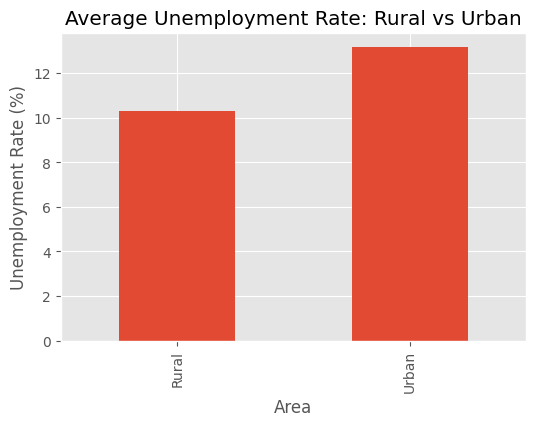

In [133]:
area_avg = df.groupby('Area')['Unemployment_Rate'].mean()

plt.figure(figsize=(6,4))
area_avg.plot(kind='bar')

plt.title('Average Unemployment Rate: Rural vs Urban')
plt.ylabel('Unemployment Rate (%)')
plt.show()

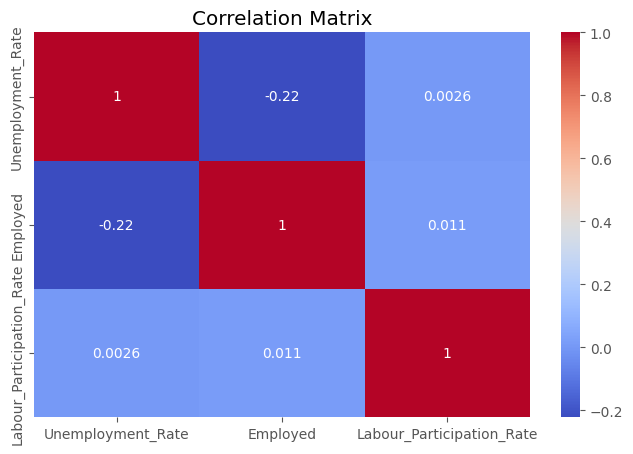

In [134]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Unemployment_Rate',
        'Employed',
        'Labour_Participation_Rate']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

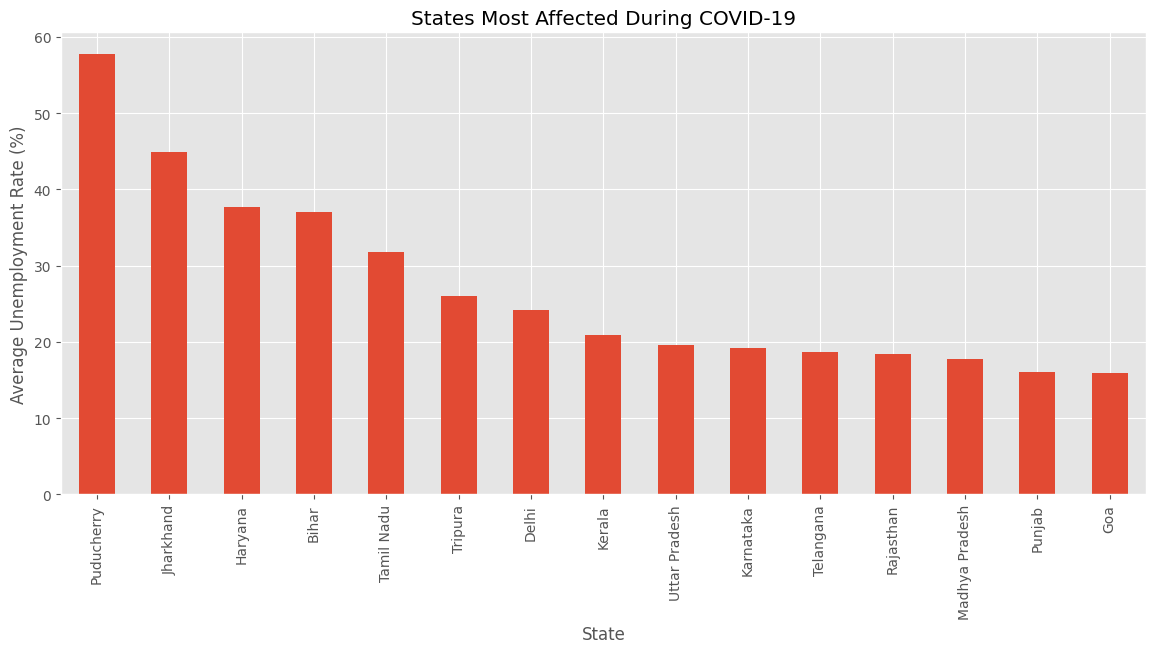

In [135]:
covid_states = df[df['Date'] >= '2020-04-01']

state_covid = covid_states.groupby('State')['Unemployment_Rate'].mean()

plt.figure(figsize=(14,6))

state_covid.sort_values(ascending=False).head(15).plot(kind='bar')

plt.title('States Most Affected During COVID-19')
plt.ylabel('Average Unemployment Rate (%)')
plt.show()